In [1]:
# Explanation Style and Human Understanding in AI Systems

## CS 6795 Cognitive Science  
Self-Directed Term Project Computational Model/Tool Track  

---

## Overview

This notebook implements a computational prototype to examine how different explanation styles influence human understanding of AI-generated decisions.

The system generates two explanation formats for the same decision:
- Structured step-by-step explanation
- Concise summary explanation

The goal is to analyze how explanation structure affects cognitive processing, particularly in terms of cognitive load and mental model formation.

---

## Research Question

How do structured step-by-step explanations versus concise summary explanations affect cognitive load and mental model formation in human understanding of AI-generated decisions?

---

## Cognitive Science Foundations

This project is grounded in key cognitive science theories:

- **Mental Model Theory (Johnson-Laird)**  
  Explains how individuals construct internal representations to understand systems and reasoning processes.

- **Cognitive Load Theory (Sweller)**  
  Describes how working memory limitations affect information processing and comprehension.

- **Information Processing Theory**  
  Explains how information is encoded, structured, and integrated into understanding.

- **Explanatory Coherence (Thagard)**  
  Suggests that structured and coherent explanations improve reasoning and understanding.

---

## Implementation Summary

The prototype is implemented using a rule-based approach.

For each simulated decision scenario, the system:
1. Accepts a decision outcome and contributing factors
2. Generates:
   - A step-by-step explanation (multiple reasoning steps)
   - A summary explanation (single compressed reasoning step)
3. Computes simple quantitative indicators:
   - Word count
   - Step count
   - Information density
   - Estimated cognitive load (proxy measure)

---

## Purpose of the Notebook

This notebook demonstrates:
- The implementation of the explanation generation system
- A comparison between explanation styles
- Quantitative indicators used to approximate cognitive processing differences

The results are used to support analysis in the final report.

SyntaxError: invalid syntax (2021935865.py, line 4)

In [5]:
# -------------------------------
# Explanation Generator Functions
# -------------------------------

def generate_step_by_step(data):
    decision = data.get("decision", "Unknown decision")
    factors = data.get("factors", [])

    explanation_parts = [f"The final decision is: {decision}."]

    for i, item in enumerate(factors, start=1):
        factor = item.get("factor", "Unknown factor")
        explanation_parts.append(
            f"Step {i}: {factor} contributed to the final decision."
        )

    explanation_parts.append(
        "After considering all relevant factors, the system produced the final decision."
    )

    return " ".join(explanation_parts)


def generate_summary(data):
    decision = data.get("decision", "Unknown decision")
    factors = data.get("factors", [])

    factor_names = [item.get("factor", "Unknown factor") for item in factors]

    if factor_names:
        return (
            f"The final decision is: {decision}. "
            f"Step 1: The decision is based on key factors including {', '.join(factor_names)}."
        )

    return (
        f"The final decision is: {decision}. "
        f"Step 1: The decision is based on the available information."
    )

In [6]:
# -------------------------------
# Metrics Functions
# -------------------------------

def count_words(text):
    return len(text.split())


def count_steps(text):
    return text.count("Step")


def information_density(num_factors, num_words):
    if num_words == 0:
        return 0
    return round(num_factors / num_words, 3)


def estimate_cognitive_load(num_words, num_steps):
    # simple proxy (for assignment purposes only)
    return round((0.5 * num_words) + (2 * num_steps), 2)


def compute_metrics(explanation, num_factors):
    words = count_words(explanation)
    steps = count_steps(explanation)
    density = information_density(num_factors, words)
    cognitive_load = estimate_cognitive_load(words, steps)

    return {
        "word_count": words,
        "step_count": steps,
        "information_density": density,
        "estimated_cognitive_load": cognitive_load
    }

In [7]:
# -------------------------------
# Expanded Test Cases
# -------------------------------

cases = {
    "Loan Approval": {
        "decision": "Loan Approved",
        "factors": [
            {"factor": "High income"},
            {"factor": "Good credit score"},
            {"factor": "Low existing debt"},
            {"factor": "Stable employment history"},
            {"factor": "Limited recent credit inquiries"},
        ],
    },
    "Loan Rejection": {
        "decision": "Loan Rejected",
        "factors": [
            {"factor": "Low income"},
            {"factor": "Poor credit score"},
            {"factor": "High existing debt"},
            {"factor": "Short employment history"},
            {"factor": "Multiple recent missed payments"},
        ],
    },
    "Job Screening": {
        "decision": "Candidate Selected for Interview",
        "factors": [
            {"factor": "Relevant work experience"},
            {"factor": "Strong technical assessment score"},
            {"factor": "Clear communication skills"},
            {"factor": "Experience with similar tools"},
            {"factor": "Consistent project portfolio"},
        ],
    },
    "Job Rejection": {
        "decision": "Candidate Not Selected for Interview",
        "factors": [
            {"factor": "Limited relevant experience"},
            {"factor": "Weak technical assessment score"},
            {"factor": "Unclear project examples"},
            {"factor": "Skills mismatch with job requirements"},
            {"factor": "Incomplete application materials"},
        ],
    },
    "Medical Risk Assessment": {
        "decision": "High Risk Classification",
        "factors": [
            {"factor": "Elevated blood pressure"},
            {"factor": "High cholesterol level"},
            {"factor": "Family history of disease"},
            {"factor": "Sedentary lifestyle"},
            {"factor": "Elevated blood sugar level"},
        ],
    },
    "Insurance Pricing": {
        "decision": "Higher Premium Assigned",
        "factors": [
            {"factor": "Multiple prior claims"},
            {"factor": "High-risk driving record"},
            {"factor": "Frequent late payments"},
            {"factor": "Long commute distance"},
            {"factor": "Recent policy lapse"},
        ],
    },
}

In [8]:
# -------------------------------
# Run Model
# -------------------------------

results = []

for case_name, data in cases.items():
    print("\n" + "="*60)
    print(f"CASE: {case_name}")
    print("="*60)

    step_exp = generate_step_by_step(data)
    summary_exp = generate_summary(data)

    step_metrics = compute_metrics(step_exp, len(data["factors"]))
    summary_metrics = compute_metrics(summary_exp, len(data["factors"]))

    results.append({
        "case": case_name,
        "type": "step",
        **step_metrics
    })

    results.append({
        "case": case_name,
        "type": "summary",
        **summary_metrics
    })

    print("\n--- Step-by-step Explanation ---")
    print(step_exp)
    print(step_metrics)

    print("\n--- Summary Explanation ---")
    print(summary_exp)
    print(summary_metrics)


CASE: Loan Approval

--- Step-by-step Explanation ---
The final decision is: Loan Approved. Step 1: High income contributed to the final decision. Step 2: Good credit score contributed to the final decision. Step 3: Low existing debt contributed to the final decision. Step 4: Stable employment history contributed to the final decision. Step 5: Limited recent credit inquiries contributed to the final decision. After considering all relevant factors, the system produced the final decision.
{'word_count': 67, 'step_count': 5, 'information_density': 0.075, 'estimated_cognitive_load': 43.5}

--- Summary Explanation ---
The final decision is: Loan Approved. Step 1: The decision is based on key factors including High income, Good credit score, Low existing debt, Stable employment history, Limited recent credit inquiries.
{'word_count': 31, 'step_count': 1, 'information_density': 0.161, 'estimated_cognitive_load': 17.5}

CASE: Loan Rejection

--- Step-by-step Explanation ---
The final decisio

In [9]:
import pandas as pd

df = pd.DataFrame(results)
df

,case,type,word_count,step_count,information_density,estimated_cognitive_load
0,Loan Approval,step,67,5,0.075,43.5
1,Loan Approval,summary,31,1,0.161,17.5
2,Loan Rejection,step,67,5,0.075,43.5
3,Loan Rejection,summary,31,1,0.161,17.5
4,Job Screening,step,71,5,0.070,45.5
5,Job Screening,summary,35,1,0.143,19.5
6,Job Rejection,step,73,5,0.068,46.5
7,Job Rejection,summary,37,1,0.135,20.5
8,Medical Risk Assessment,step,69,5,0.072,44.5
9,Medical Risk Assessment,summary,33,1,0.152,18.5


In [10]:
df_pivot = df.pivot(index="case", columns="type", values="estimated_cognitive_load")
df_pivot

type,step,summary
case,,
Insurance Pricing,44.0,18.0
Job Rejection,46.5,20.5
Job Screening,45.5,19.5
Loan Approval,43.5,17.5
Loan Rejection,43.5,17.5
Medical Risk Assessment,44.5,18.5


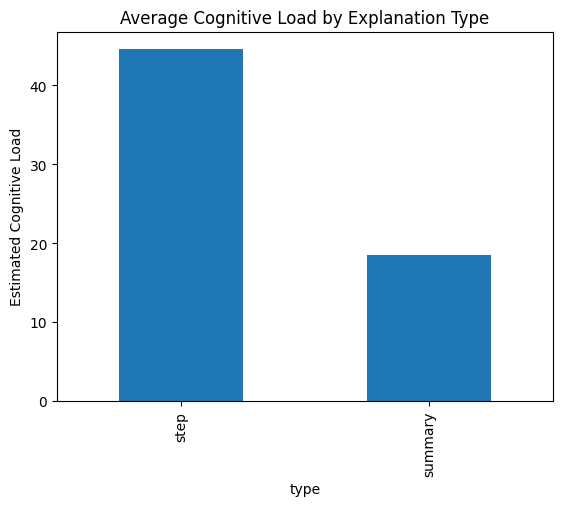

In [11]:
import matplotlib.pyplot as plt

df.groupby("type")["estimated_cognitive_load"].mean().plot(kind="bar")
plt.title("Average Cognitive Load by Explanation Type")
plt.ylabel("Estimated Cognitive Load")
plt.show()